In [54]:
import torch
import torch.nn.functional as F
from collections import defaultdict
from sklearn.metrics import mean_squared_error
from torch.utils.data import DataLoader
import numpy as np
from scipy.signal import welch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.linear_model import Ridge
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.data.H5_dataset import EEGH5Dataset
from src.models.embedder import cEmbedder
from src.models.recovery import cRecovery
from src.models.supervisor import Supervisor
from src.losses.losses import supervised_loss
from src.utils.config import (
    LATENT_DIM,
    LR_SUPERVISOR,
    EPOCHS_SUPERVISOR,
    WINDOW_SIZE,
    WINDOW_STRIDE,
    BATCH_SIZE,
    WANTED_CHANNELS,
    NUM_LAYERS_EMBEDDER,
    NUM_LAYERS_RECOVERY,
    NUM_LAYERS_SUPERVISOR,
    NUM_CHANNELS
)
from src.utils.logging import get_logger

In [55]:
logger = get_logger("Evaluate Supervisor")

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [57]:
test_dataset = EEGH5Dataset("C:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\data\\processed\\eeg_test.h5")

In [58]:
dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

logger.info(f"Dataset windows: {len(test_dataset)}")

2026-05-29 12:23:04 | INFO | Dataset windows: 6660


In [59]:
E = cEmbedder(
    x_dim=NUM_CHANNELS,
    h_dim=LATENT_DIM,
    num_layers=NUM_LAYERS_EMBEDDER
).to(device)

R = cRecovery(
    h_dim=LATENT_DIM,
    x_dim=NUM_CHANNELS,
    num_layers=NUM_LAYERS_RECOVERY
).to(device)

S = Supervisor(
    h_dim=LATENT_DIM,
    num_layers=NUM_LAYERS_SUPERVISOR
).to(device)

logger.info("Embedder and Supervisor initialized")

2026-05-29 12:23:04 | INFO | Embedder and Supervisor initialized


In [60]:
E.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\embedder_12.0.pt", weights_only=True))
R.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\recovery_12.0.pt", weights_only=True))
S.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\supervisor_12.0.pt", weights_only=True))

<All keys matched successfully>

In [61]:
@torch.no_grad()
def supervisor_one_step_error(embedder, supervisor, dataloader, device):
    embedder.eval()
    supervisor.eval()

    errors = []
    baseline_errors = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        z, _ = embedder(x, y)            # (B, T, D)

        z_input = z[:, :-1, :]
        z_target = z[:, 1:, :]

        z_pred = supervisor(z_input, y)

        # Supervisor error
        err = torch.mean((z_pred - z_target) ** 2).item()
        errors.append(err)

        # Persistence baseline: Z_t predicts Z_{t+1}
        baseline = z_input
        base_err = torch.mean((baseline - z_target) ** 2).item()
        baseline_errors.append(base_err)

    return {
        "supervisor_mse": np.mean(errors),
        "persistence_mse": np.mean(baseline_errors),
    }

In [73]:
mse = supervisor_one_step_error(E, S, dataloader, device)

In [63]:
def ar1_baseline_mse(E, dataloader, device):
    E.eval()
    all_h = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            h, _ = E(x, y)                        # (B, T, H)
            all_h.append(h.cpu().numpy())

    all_h = np.concatenate(all_h, axis=0)         # (N, T, H)

    X = all_h[:, :-1, :].reshape(-1, all_h.shape[-1])   # (N*(T-1), H)
    Y = all_h[:, 1:,  :].reshape(-1, all_h.shape[-1])   # (N*(T-1), H)

    ar = Ridge(alpha=1e-3).fit(X, Y)
    ar1_mse = mean_squared_error(Y, ar.predict(X))

    return ar1_mse, ar

In [64]:
def residual_whiteness_test(E, S, dataloader, device, lags=20):
    E.eval(); S.eval()
    all_residuals = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            h, _  = E(x, y)                       # (B, T, H)
            h_hat = S(h[:, :-1, :], y)            # (B, T-1, H)
            residuals = (h[:, 1:, :] - h_hat)     # (B, T-1, H)
            all_residuals.append(residuals.cpu().numpy())

    all_residuals = np.concatenate(all_residuals, axis=0)  # (N, T-1, H)
    n_dims        = all_residuals.shape[-1]
    results       = {}

    for dim in range(n_dims):
        r  = all_residuals[:, :, dim].mean(axis=0)         # (T-1,) mean over batch
        lb = acorr_ljungbox(r, lags=lags, return_df=True)
        results[f'dim_{dim}'] = lb['lb_pvalue'].values

    white_noise_dims = sum(1 for v in results.values() if (v > 0.05).all())
    print(f"White noise residuals: {white_noise_dims}/{n_dims} dims")

    return results

In [65]:
def rollout_mse(E, S, dataloader, device):
    E.eval(); S.eval()
    all_mse_curves = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            h, _ = E(x, y)                        # (B, T, H)
            T    = h.shape[1]

            # Seed with t=0, roll out autoregressively for T-1 steps
            h_pred = [h[:, 0:1, :]]               # [(B, 1, H)]
            for _ in range(1, T):
                next_h = S(h_pred[-1], y)         # (B, 1, H)
                h_pred.append(next_h)

            h_pred = torch.cat(h_pred, dim=1)     # (B, T, H)

            # MSE at each step, averaged over batch and hidden dims
            mse_per_step = ((h_pred - h) ** 2).mean(dim=(0, 2))  # (T,)
            all_mse_curves.append(mse_per_step.cpu().numpy())

    mean_curve = np.stack(all_mse_curves).mean(axis=0)   # (T,)

    plt.figure(figsize=(8, 4))
    plt.plot(mean_curve)
    plt.xlabel("Rollout step")
    plt.ylabel("MSE")
    plt.title("Autoregressive rollout error growth")
    plt.tight_layout()
    plt.show()

    return mean_curve

In [66]:
def run_supervisor_tests(E, S, dataloader, device):
    ar1_mse, _    = ar1_baseline_mse(E, dataloader, device)
    whiteness     = residual_whiteness_test(E, S, dataloader, device)
    rollout_curve = rollout_mse(E, S, dataloader, device)

    white_pct = sum(
        1 for v in whiteness.values() if (v > 0.05).all()
    ) / len(whiteness) * 100

    print(f"\n── Supervisor Test Summary ──────────────────")
    print(f"AR(1) MSE          : {ar1_mse:.6f}")
    print(f"White noise dims   : {white_pct:.0f}%")
    print(f"Rollout step-1 MSE : {rollout_curve[1]:.6f}")
    print(f"Rollout final MSE  : {rollout_curve[-1]:.6f}")
    print(f"Rollout divergence : {rollout_curve[-1] / rollout_curve[1]:.1f}x")

White noise residuals: 0/12 dims


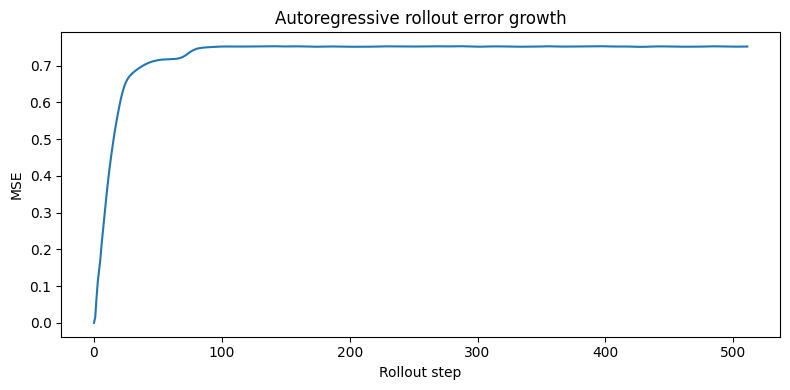


── Supervisor Test Summary ──────────────────
AR(1) MSE          : 0.000771
White noise dims   : 0%
Rollout step-1 MSE : 0.014907
Rollout final MSE  : 0.751778
Rollout divergence : 50.4x


In [67]:
run_supervisor_tests(E, S, dataloader, device)

In [87]:
with torch.no_grad():
    all_h = []
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        h, _ = E(x, y)
        all_h.append(h)

all_h = torch.cat(all_h)
latent_var = all_h.var(dim=(0,1)).mean().item()  # mean variance across H dims
print(f"Latent variance : {latent_var:.4f}")
print(f"Rollout plateau : 0.74")
print(f"Ratio           : {0.74 / latent_var:.2f}x")

Latent variance : 0.6510
Rollout plateau : 0.74
Ratio           : 1.14x


In [68]:
def per_class_mse(S, E, dataloader, device):
    class_losses = defaultdict(list)
    S.eval(); E.eval()
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            h, _ = E(x, y)
            h_hat = S(h[:, :-1, :], y)
            
            for cls in y.unique():
                mask = y == cls
                mse  = F.mse_loss(
                    h_hat[mask], h[:, 1:, :][mask]
                ).item()
                class_losses[cls.item()].append(mse)
    
    return {cls: np.mean(v) for cls, v in class_losses.items()}

In [69]:
def shuffled_baseline_mse(S, E, dataloader, device):
    losses = []
    S.eval(); E.eval()
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            h, _ = E(x, y)
            
            # Randomly permute time axis
            idx      = torch.randperm(h.shape[1])
            h_shuf   = h[:, idx, :]
            h_hat    = S(h_shuf[:, :-1, :], y)
            
            losses.append(
                F.mse_loss(h_hat, h_shuf[:, 1:, :]).item()
            )
    
    return np.mean(losses)

In [70]:
class_mse = per_class_mse(S, E, dataloader, device)
for cls, mse in sorted(class_mse.items()):
    print(f"Class {cls:2d}: MSE = {mse:.6f}")

Class  0: MSE = 0.000156
Class  1: MSE = 0.000181
Class  2: MSE = 0.000211
Class  3: MSE = 0.000179
Class  4: MSE = 0.000207
Class  5: MSE = 0.000146
Class  6: MSE = 0.000155
Class  7: MSE = 0.000161
Class  8: MSE = 0.000138
Class  9: MSE = 0.000151
Class 10: MSE = 0.000181
Class 11: MSE = 0.000231
Class 12: MSE = 0.000176
Class 13: MSE = 0.000167
Class 14: MSE = 0.000157


In [81]:
sup_mse = mse['supervisor_mse']

In [83]:
shuffled_mse = shuffled_baseline_mse(S, E, dataloader, device)
print(f"Real sequence MSE  : {sup_mse:.6f}")
print(f"Shuffled sequence  : {shuffled_mse:.6f}")
print(f"Ratio              : {shuffled_mse / sup_mse:.1f}x")

Real sequence MSE  : 0.000173
Shuffled sequence  : 0.033834
Ratio              : 195.3x
